# 08 - Conditional VAE

Notebook para entrenar el `ConditionalVAE` usando el mismo flujo que el AutoEncoder/VAE: dataset, validacion, scheduler, early stopping, guardado del mejor modelo y log de resultados.


In [3]:
%run init_notebook.py

import os
import time
from pathlib import Path

import torch
import torch.nn.functional as F
import torch.optim as optim
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import DATA_PATH, LOGS_PATH
from src.dataset import NSynth, nsynth_collate_fn
from src.losses import MultiDecoderLoss
from src.models2_latent import ConditionalVAE
from src.utils.logger import save_training_results

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

MODEL_DIR = DATA_PATH / 'models'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / 'cvae5_latent.pth'
#model_path = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae.pth"
print('Modelo:', model_path)


Device: cuda
GPU: NVIDIA GeForce RTX 3090
Modelo: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae5_latent.pth


In [ ]:
# Hiperparametros de audio / Mel
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160
N_MELS = 80
MAX_FRAMES = 128
INPUT_SIZE = (N_MELS, MAX_FRAMES)

# Hiperparametros de entrenamiento
EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
PATIENCE_ES = 10
NUM_WORKERS = 2  # en Windows/Jupyter suele ser mas estable que 2+
PIN_MEMORY = DEVICE.type == 'cuda'
RESUME = True
SAVE_EVERY = 5
GRAD_CLIP_NORM = 5.0

# Hiperparametros del modelo
LATENT_DIM = 128#256
CHANNELS = [1, 32, 64, 128, 256]
CONDITION_DIM = 128
N_HARMONICS = 64
DDSP_HIDDEN = 256

# Hiperparametros de la loss
BETA_MAX = 0.0005#0.01#0.1
BETA_WARMUP_EPOCHS = 20 #5
LAMBDA_MEL = 3.0 #antes 1
LAMBDA_DDSP = 0.0

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
).to(DEVICE)


def waveforms_to_mel(waveforms):
    """Convierte waveform [B,1,T] a log-Mel [B,1,N_MELS,MAX_FRAMES]."""
    mel = mel_transform(waveforms)
    mel = torch.log1p(mel)

    if mel.shape[-1] > MAX_FRAMES:
        mel = mel[..., :MAX_FRAMES]
    elif mel.shape[-1] < MAX_FRAMES:
        mel = F.pad(mel, (0, MAX_FRAMES - mel.shape[-1]))

    return mel


def stack_feature(value, device):
    """Collate robusto por si algun .pt tiene distinta longitud de frames."""
    if torch.is_tensor(value):
        return value.float().to(device, non_blocking=True)

    max_len = max(v.shape[-1] for v in value)
    padded = []
    for v in value:
        v = v.float()
        if v.shape[-1] < max_len:
            v = F.pad(v, (0, max_len - v.shape[-1]))
        else:
            v = v[..., :max_len]
        padded.append(v)
    return torch.stack(padded).to(device, non_blocking=True)


def conditions_to_device(conditions, device):
    return {
        'instrument_onehot': conditions['instrument_onehot'].float().to(device, non_blocking=True),
        'pitch_norm': conditions['pitch_norm'].float().to(device, non_blocking=True),
        'velocity_norm': conditions['velocity_norm'].float().to(device, non_blocking=True),
        'brightness': conditions['brightness'].float().to(device, non_blocking=True),
        'sustain': conditions['sustain'].float().to(device, non_blocking=True),
    }


In [5]:
# Features extraidas por Extract_features.py.  
FEATURES_ROOT = DATA_PATH / 'nsynth_features'
TRAIN_FEATURES_DIR = FEATURES_ROOT / 'train'
VALID_FEATURES_DIR = FEATURES_ROOT / 'validation'


def build_nsynth_dataset(partition, features_dir):
    ds = NSynth(
        partition=partition,
        features_dir=str(features_dir),
        require_features=True,
    )
    return ds

print('Cargando training...')
train_dataset = build_nsynth_dataset('training', TRAIN_FEATURES_DIR)

valid_dataset = NSynth(
    partition='validation',
    features_dir='data/nsynth_features/validation',
    require_features=True,
)

if VALID_FEATURES_DIR.exists():
    print('Cargando validation...')
    valid_dataset = build_nsynth_dataset('validation', VALID_FEATURES_DIR)
    if len(valid_dataset) == 0:
        print('Validation no tiene .pt compatibles; se entrenara sin validacion.')
        valid_dataset = None
else:
    print(f'No existe {VALID_FEATURES_DIR}; se entrenara sin validacion.')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=nsynth_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=nsynth_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

if valid_dataset is not None:
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=nsynth_collate_fn,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

print('Train samples:', len(train_dataset))
print('Valid samples:', 0 if valid_dataset is None else len(valid_dataset))
print('Train batches:', len(train_loader))


Cargando training...
Carga completada: 289205 muestras de todos los instrumentos.
Carga completada: 12678 muestras de todos los instrumentos.
[NSynth] require_features=True: 12678 samples sin .pt omitidos (0 disponibles)
Cargando validation...
Carga completada: 12678 muestras de todos los instrumentos.
Train samples: 289205
Valid samples: 12678
Train batches: 18076


In [6]:
model = ConditionalVAE(
    input_size=INPUT_SIZE,
    latent_dim=LATENT_DIM,
    channels=CHANNELS,
    condition_dim=CONDITION_DIM,
    n_frames=MAX_FRAMES,
    n_harmonics=N_HARMONICS,
    ddsp_hidden=DDSP_HIDDEN,
).to(DEVICE)

if RESUME and model_path.exists():
    state = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state)
    print('Modelo cargado desde checkpoint existente.')
else:
    print('Entrenando desde cero.')

beta_steps = max(1, len(train_loader) * BETA_WARMUP_EPOCHS)
loss_fn = MultiDecoderLoss(
    beta_max=BETA_MAX,
    beta_steps=beta_steps,
    lambda_mel=LAMBDA_MEL,
    lambda_ddsp=LAMBDA_DDSP,
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros entrenables: {n_params:,}')
print(f'Beta warmup steps: {beta_steps}')


Entrenando desde cero.
Parametros entrenables: 1,654,979
Beta warmup steps: 903800


In [8]:
# Smoke test de shapes antes de lanzar el entrenamiento completo.
batch = next(iter(train_loader))
#waveforms,mels, srs, keys, metadatas, features, conditions = batch
mels, keys, metadatas, features, conditions = batch
#waveforms = waveforms.to(DEVICE, non_blocking=True)
#mel_orig = waveforms_to_mel(waveforms)
mels = mels.to(
    DEVICE,
    non_blocking=True
)

mel_orig = mels
cond = conditions_to_device(conditions, DEVICE)

with torch.no_grad():
    mel_hat, ddsp_params, kld = model(
        mel_orig,
        cond['instrument_onehot'],
        cond['pitch_norm'],
        cond['velocity_norm'],
        cond['brightness'],
        cond['sustain'],
    )

print('mel_orig:', tuple(mel_orig.shape))
print('mel_hat :', tuple(mel_hat.shape))
print('f0      :', tuple(ddsp_params['f0_scale'].shape))
print('loudness:', tuple(ddsp_params['loudness_scale'].shape))
print('harm    :', tuple(ddsp_params['harmonics'].shape))
print('kld     :', tuple(kld.shape))


mel_orig: (16, 1, 80, 128)
mel_hat : (16, 1, 80, 128)
f0      : (16, 128)
loudness: (16, 128)
harm    : (16, 128, 64)
kld     : (16,)


In [10]:
#el checkpoint, early stopping y scheduler usan la misma métrica, metric = mel reconstruction loss
def run_epoch(loader, train=True):
    model.train(train)
    totals = {
        'total': 0.0,
        'mel': 0.0,
        'ddsp': 0.0,
        'f0': 0.0,
        'loudness': 0.0,
        'kld': 0.0,
        'beta': 0.0,
    }
    n_seen = 0

    desc = 'train' if train else 'valid'
    iterator = tqdm(loader, desc=desc, leave=False)
    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch in iterator:
            mels,  keys, metadatas, features, conditions = batch
           # waveforms = waveforms.to(DEVICE, non_blocking=True)
           # mel_orig = waveforms_to_mel(waveforms)
            mels = mels.to(DEVICE, non_blocking=True)
            mel_orig = mels 
            cond = conditions_to_device(conditions, DEVICE)
            features_real = {
                'f0': stack_feature(features['f0'], DEVICE),
                'loudness_db': stack_feature(features['loudness_db'], DEVICE),
            }

            if train:
                optimizer.zero_grad(set_to_none=True)

            mel_hat, ddsp_params, kld = model(
                mel_orig,
                cond['instrument_onehot'],
                cond['pitch_norm'],
                cond['velocity_norm'],
                cond['brightness'],
                cond['sustain'],
            )
            loss, loss_dict = loss_fn(mel_orig, mel_hat, ddsp_params, features_real, kld)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
                loss_fn.step_beta()

            batch_size = mels.shape[0] #waveforms.shape[0]
            n_seen += batch_size
            totals['total'] += loss.item() * batch_size
            for key in ['mel', 'ddsp', 'f0', 'loudness', 'kld', 'beta']:
                    totals[key] += float(loss_dict[key]) * batch_size

            iterator.set_postfix(
                loss=f'{loss.item():.4f}',
                mel=f"{loss_dict['mel']:.4f}",
                ddsp=f"{loss_dict['ddsp']:.4f}",
                beta=f"{loss_dict['beta']:.4f}",
            )

    return {key: value / max(1, n_seen) for key, value in totals.items()}


history = {
    'train_total': [], 'train_mel': [], 'train_ddsp': [], 'train_f0': [],
    'train_loudness': [], 'train_kld': [], 'train_beta': [],
    'valid_total': [], 'valid_mel': [], 'valid_ddsp': [], 'valid_f0': [],
    'valid_loudness': [], 'valid_kld': [], 'valid_beta': [],
}

best_metric = float('inf')
epochs_no_improve = 0
total_epoch_time = 0.0

print('Starting training on', DEVICE)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_stats = run_epoch(train_loader, train=True)
    for key, value in train_stats.items():
        history[f'train_{key}'].append(value)

    if valid_loader is not None:
        valid_stats = run_epoch(valid_loader, train=False)
        for key, value in valid_stats.items():
            history[f'valid_{key}'].append(value)

       # metric = valid_stats['total']   # usamos validation loss
        metric = valid_stats['mel']

    else:
        valid_stats = None
        metric = train_stats['mel']   # fallback si no hay validation
        """
        metric = (
            train_stats['mel']
            + 0.5 * train_stats['ddsp']
            + train_stats['beta'] * train_stats['kld']
        )
        """

    scheduler.step(metric)

    epoch_time = time.time() - start
    total_epoch_time += epoch_time

    if valid_stats is None:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_stats['total']:.4f} "
            f"mel={train_stats['mel']:.4f} ddsp={train_stats['ddsp']:.4f} "
            f"kld={train_stats['kld']:.4f¡} beta={train_stats['beta']:.4f} "
            f"time={epoch_time:.1f}s"
        )
    else:
       print(
            f"Epoch {epoch:03d} | "
            f"train={train_stats['total']:.4f} valid={valid_stats['total']:.4f} "
            f"metric={metric:.4f} "
            f"mel={valid_stats['mel']:.4f} ddsp={valid_stats['ddsp']:.4f} "
            f"kld={valid_stats['kld']:.4f} beta={valid_stats['beta']:.4f} "
            f"time={epoch_time:.1f}s"
        )

    if metric < best_metric:
        best_metric = metric¡'¡'
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_path)
        print(f'  Mejor modelo guardado en: {model_path}')
    else:
        epochs_no_improve += 1

    if epoch % SAVE_EVERY == 0:
        epoch_ckpt = CHECKPOINT_DIR / f'cvae_epoch_{epoch:03d}.pth'
        torch.save(model.state_dict(), epoch_ckpt)
        print(f'  Checkpoint guardado en: {epoch_ckpt}')

    if epochs_no_improve >= PATIENCE_ES:
        print(f'Early stopping en epoch {epoch}.')
        break

print('Training complete.')


Starting training on cuda


Epoch 001 | train=0.4432 valid=0.3096 metric=0.0876 mel=0.0876 ddsp=0.1351 kld=4681.1704 beta=0.0000 time=2764.5s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae5_latent.pth


Epoch 002 | train=0.2618 valid=0.2544 metric=0.0659 mel=0.0659 ddsp=0.1348 kld=2837.9247 beta=0.0000 time=953.4s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae5_latent.pth


Epoch 003 | train=0.2473 valid=0.2509 metric=0.0613 mel=0.0613 ddsp=0.1347 kld=2233.5877 beta=0.0000 time=953.7s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae5_latent.pth


Epoch 004 | train=0.2453 valid=0.2585 metric=0.0609 mel=0.0609 ddsp=0.1346 kld=1896.3685 beta=0.0000 time=957.7s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae5_latent.pth


...

Epoch 011 | train=0.2959 valid=0.3153 metric=0.0656 mel=0.0656 ddsp=0.1347 kld=1078.2524 beta=0.0001 time=979.0s


Epoch 012 | train=0.3052 valid=0.3188 metric=0.0646 mel=0.0646 ddsp=0.1347 kld=1042.9219 beta=0.0001 time=1076.0s


Epoch 013 | train=0.3140 valid=0.3278 metric=0.0661 mel=0.0661 ddsp=0.1347 kld=996.5921 beta=0.0001 time=2707.1s


Epoch 014 | train=0.3203 valid=0.3337 metric=0.0662 mel=0.0662 ddsp=0.1347 kld=964.0697 beta=0.0001 time=953.9s


Epoch 015 | train=0.3286 valid=0.3423 metric=0.0671 mel=0.0671 ddsp=0.1347 kld=940.4547 beta=0.0001 time=948.9s
  Checkpoint guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\checkpoints\cvae_epoch_015.pth
Early stopping en epoch 15.
Training complete.


In [ ]:
results = {
    'train_total': history['train_total'],
    'train_mel': history['train_mel'],
    'train_ddsp': history['train_ddsp'],
    'train_f0': history['train_f0'],
    'train_loudness': history['train_loudness'],
    'train_kld': history['train_kld'],
    'train_beta': history['train_beta'],
    'valid_total': history['valid_total'],
    'valid_mel': history['valid_mel'],
    'valid_ddsp': history['valid_ddsp'],
    'valid_f0': history['valid_f0'],
    'valid_loudness': history['valid_loudness'],
    'valid_kld': history['valid_kld'],
    'valid_beta': history['valid_beta'],
    'num_epochs': len(history['train_total']),
    'avg_epoch_time': total_epoch_time / max(1, len(history['train_total'])),
    'best_metric': best_metric,
    'model_path': str(model_path),
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'sample_rate': SAMPLE_RATE,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'n_mels': N_MELS,
    'max_frames': MAX_FRAMES,
    'input_size': INPUT_SIZE,
    'latent_dim': LATENT_DIM,
    'channels': CHANNELS,
    'condition_dim': CONDITION_DIM,
    'n_harmonics': N_HARMONICS,
    'beta_max': BETA_MAX,
    'beta_warmup_epochs': BETA_WARMUP_EPOCHS,
    'lambda_mel': LAMBDA_MEL,
    'lambda_ddsp': LAMBDA_DDSP,
}

save_training_results(results, 'cvae.json')
print('Resultados guardados en:', LOGS_PATH / 'cvae.json')
print('Mejor modelo:', model_path)


Resultados guardados en: C:\Users\Articuno\Desktop\TFG-MUSICAL\logs\cvae.json
Mejor modelo: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae4_latent.pth


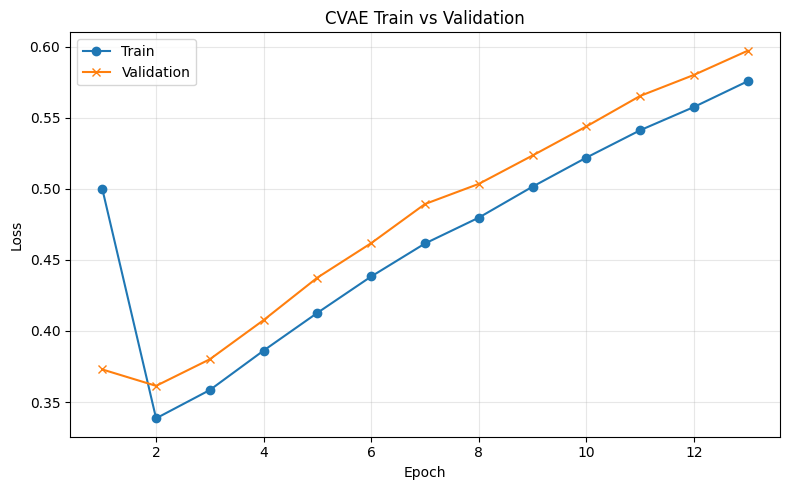

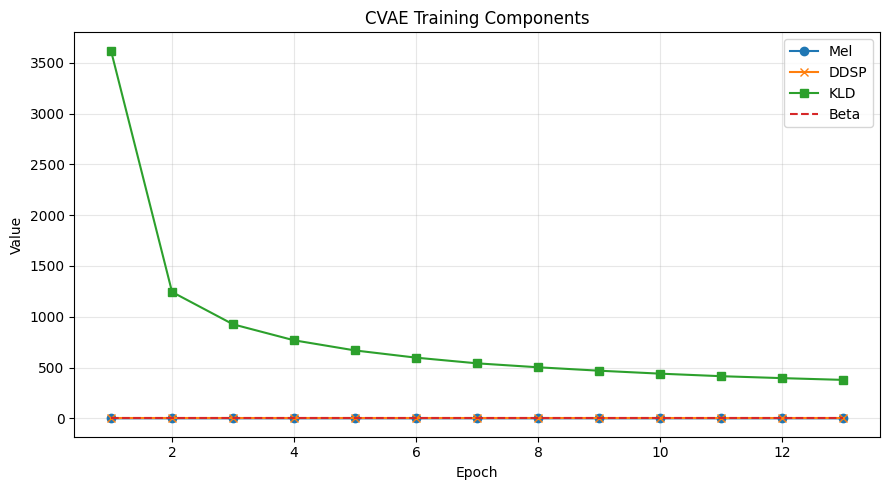

In [ ]:
epochs = range(1, len(history['train_total']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_total'], label='Train', marker='o')
if history['valid_total']:
    plt.plot(epochs, history['valid_total'], label='Validation', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CVAE Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, history['train_mel'], label='Mel', marker='o')
plt.plot(epochs, history['train_ddsp'], label='DDSP', marker='x')
plt.plot(epochs, history['train_kld'], label='KLD', marker='s')
plt.plot(epochs, history['train_beta'], label='Beta', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('CVAE Training Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import Audio, display
import torchaudio.transforms as T
import torch

# 1. Aseguramos el dispositivo y cargamos el mejor modelo de la validación
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Cargando el cerebro de la IA...")

# IMPORTANTE: asegurarse d que los canales y todo coinciden con cómo entrenamos
# Si cambiaste algo, ponlo igual aquí.
#model.load_state_dict(torch.load("checkpoints/cvae_best_val.pt"))
state = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval() # Apagamos el modo entrenamiento

# PANEL DE CONTROL 
# Familias NSynth: 0=bass, 1=brass, 2=flute, 3=guitar, 4=keyboard...
ELEGIR_INSTRUMENTO = 3 # 3 = Guitarra
ELEGIR_PITCH = 60      # 60 = Do central
ELEGIR_VELOCITY = 100  # Fuerza (0-127)
ELEGIR_BRILLO = 0.8    # 0.0 a 1.0 (0.8 = bastante brillante)
ELEGIR_SUSTAIN = 0.6   # 0.0 a 1.0 (0.2 = decae rápido, típico de guitarra)

# 🧮 TRADUCCIÓN A TENSORES
inst_oh = torch.zeros(1, 11).to(DEVICE)
inst_oh[0, ELEGIR_INSTRUMENTO] = 1.0

pitch_n = torch.tensor([[ELEGIR_PITCH / 127.0]]).to(DEVICE)
vel_n = torch.tensor([[ELEGIR_VELOCITY / 127.0]]).to(DEVICE)
bright = torch.tensor([[ELEGIR_BRILLO]]).to(DEVICE)
sustain = torch.tensor([[ELEGIR_SUSTAIN]]).to(DEVICE)

# GENERACIÓN DESDE CERO
print(f"Generando Familia {ELEGIR_INSTRUMENTO} en MIDI {ELEGIR_PITCH}...")

with torch.no_grad():
    # Usamos tu método 'sample' directamente
    mel_generado, ddsp_generado = model.sample(
        inst_oh, pitch_n, vel_n, bright, sustain, n_samples=1
    )

# ESCUCHAR con Griffin-Lim)

print("Traduciendo el espectrograma a audio...")
print(mel_generado.shape)

# Parámetros (los mismos del entrenamiento)
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160
N_MELS = 80
N_STFT = N_FFT // 2 + 1  # Esto da exactamente 513

# 1. El estirador: Pasa de 80 bandas Mel a 513 bandas Lineales
inverse_mel = T.InverseMelScale(
    n_stft=N_STFT,
    n_mels=N_MELS,
    sample_rate=SAMPLE_RATE
).to(DEVICE)

# 2. El vocoder: Pasa de 513 bandas Lineales a Onda de Audio pura
griffin_lim = T.GriffinLim(
    n_fft=N_FFT, 
    hop_length=HOP_LENGTH, 
    power=2.0
).to(DEVICE)

with torch.no_grad():
    # mel_generado tiene shape (1, 1, 80, 128). Nos quedamos con la imagen [0]
    mel_img = mel_generado[0]
    
    # Aplicamos el puente
    mel_lineal = torch.expm1(mel_img)
    mel_lineal = mel_lineal.clamp_min(0.0)

    espectrograma_lineal = inverse_mel(mel_lineal)
    audio_waveform = griffin_lim(espectrograma_lineal)

print("¡Audio listo! Dale al play:")
display(Audio(audio_waveform.cpu().squeeze().numpy(), rate=SAMPLE_RATE))

Cargando el cerebro de la IA...
Generando Familia 1 en MIDI 60...
Traduciendo el espectrograma a audio...
torch.Size([1, 1, 80, 128])
¡Audio listo! Dale al play:


In [ ]:
import random
from IPython.display import Audio, display
import torchaudio.transforms as T
import torch

# Carga del modelo (una sola vez) 
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Cargando el cerebro de la IA...")
state = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

# Vocoder (Mel -> audio), se crea una sola vez 
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160
N_MELS = 80
N_STFT = N_FFT // 2 + 1  # 513

inverse_mel = T.InverseMelScale(
    n_stft=N_STFT, n_mels=N_MELS, sample_rate=SAMPLE_RATE
).to(DEVICE)

griffin_lim = T.GriffinLim(
    n_fft=N_FFT, hop_length=HOP_LENGTH, power=2.0
).to(DEVICE)

N_INSTRUMENTOS = 11
NOMBRES_INSTRUMENTOS = {
    0: 'bass', 1: 'brass', 2: 'flute', 3: 'guitar', 4: 'keyboard',
    5: 'mallet', 6: 'organ', 7: 'reed', 8: 'string', 9: 'synth_lead', 10: 'vocal',
}


def _resolver_param(valor, n, low, high, es_entero=False):
    """
    Normaliza un parametro a una lista de n valores:
      - None            -> n valores aleatorios en [low, high]
      - escalar          -> se repite n veces (mismo valor pa todas las muestras)
      - lista/tupla       -> debe tener longitud n, un valor por muestra
    """
    if valor is None:
        if es_entero:
            return [random.randint(low, high) for _ in range(n)]
        return [random.uniform(low, high) for _ in range(n)]

    if isinstance(valor, (list, tuple)):
        if len(valor) != n:
            raise ValueError(f'Se esperaban {n} valores y llegaron {len(valor)}.')
        return list(valor)

    return [valor] * n  # escalar -> mismo valor para las n muestras


def _mel_a_audio(mel_img):
    """mel_img: (1, H, W) log-mel de UNA muestra -> waveform numpy."""
    with torch.no_grad():
        mel_lineal = torch.expm1(mel_img).clamp_min(0.0)
        espectrograma_lineal = inverse_mel(mel_lineal)
        audio_waveform = griffin_lim(espectrograma_lineal)
    return audio_waveform.cpu().squeeze().numpy()


@torch.no_grad()
def generar_sonidos(n=1, instrumento=None, pitch=None, velocity=None,
                     brillo=None, sustain=None):
    """
    Genera n sonidos con el modelo.

    Cada parametro admite:
      - None                -> aleatorio, distinto por muestra
      - un valor             -> igual para las n muestras
      - lista de n valores    -> uno por muestra

    Rangos: instrumento 0-10, pitch 0-127 (MIDI), velocity 0-127,
    brillo/sustain 0.0-1.0.

    Retorna una lista de dicts: {'audio', 'config', 'mel'}
    """
    instrumentos = _resolver_param(instrumento, n, 0, N_INSTRUMENTOS - 1, es_entero=True)
    pitches      = _resolver_param(pitch, n, 24, 96, es_entero=True)     # rango tipico NSynth
    velocities   = _resolver_param(velocity, n, 25, 127, es_entero=True)
    brillos      = _resolver_param(brillo, n, 0.0, 1.0)
    sustains     = _resolver_param(sustain, n, 0.0, 1.0)

    inst_oh = torch.zeros(n, N_INSTRUMENTOS, device=DEVICE)
    for i, ins in enumerate(instrumentos):
        inst_oh[i, ins] = 1.0

    pitch_n   = torch.tensor([[p / 127.0] for p in pitches], device=DEVICE)
    vel_n     = torch.tensor([[v / 127.0] for v in velocities], device=DEVICE)
    bright_t  = torch.tensor([[b] for b in brillos], device=DEVICE)
    sustain_t = torch.tensor([[s] for s in sustains], device=DEVICE)

    mel_generado, ddsp_generado = model.sample(
        inst_oh, pitch_n, vel_n, bright_t, sustain_t, n_samples=n
    )

    resultados = []
    for i in range(n):
        audio = _mel_a_audio(mel_generado[i])
        config = {
            'instrumento': instrumentos[i],
            'instrumento_nombre': NOMBRES_INSTRUMENTOS.get(instrumentos[i], '?'),
            'pitch': pitches[i],
            'velocity': velocities[i],
            'brillo': round(brillos[i], 3),
            'sustain': round(sustains[i], 3),
        }
        resultados.append({'audio': audio, 'config': config, 'mel': mel_generado[i].cpu()})

    return resultados


def mostrar_sonidos(resultados):
    for i, r in enumerate(resultados):
        c = r['config']
        print(f"[{i}] {c['instrumento_nombre']} (fam {c['instrumento']}) | "
              f"MIDI {c['pitch']} | vel {c['velocity']} | "
              f"brillo {c['brillo']} | sustain {c['sustain']}")
        display(Audio(r['audio'], rate=SAMPLE_RATE))

Cargando el cerebro de la IA...


In [ ]:
# 5 sonidos totalmente aleatorios
resultados = generar_sonidos(n=5)
mostrar_sonidos(resultados)

# 3 guitarras (mismo instrumento), pitch distinto en cada una, resto aleatorio
resultados = generar_sonidos(n=3, instrumento=3, pitch=[48, 60, 72])
mostrar_sonidos(resultados)

# Lo mismo que tu celda original, exacto
resultados = generar_sonidos(n=1, instrumento=3, pitch=60, velocity=100, brillo=0.8, sustain=0.6)
mostrar_sonidos(resultados)

[0] keyboard (fam 4) | MIDI 53 | vel 106 | brillo 0.346 | sustain 0.226


[1] guitar (fam 3) | MIDI 75 | vel 51 | brillo 0.848 | sustain 0.831


[2] synth_lead (fam 9) | MIDI 34 | vel 107 | brillo 0.992 | sustain 0.515


[3] keyboard (fam 4) | MIDI 56 | vel 115 | brillo 0.565 | sustain 0.74


[4] reed (fam 7) | MIDI 43 | vel 124 | brillo 0.083 | sustain 0.408


[0] guitar (fam 3) | MIDI 48 | vel 53 | brillo 0.68 | sustain 0.376


[1] guitar (fam 3) | MIDI 60 | vel 62 | brillo 0.034 | sustain 0.145


[2] guitar (fam 3) | MIDI 72 | vel 124 | brillo 0.012 | sustain 0.003


[0] guitar (fam 3) | MIDI 60 | vel 100 | brillo 0.8 | sustain 0.6
